In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import random

import os
import numpy as np
import pandas as pd
import glob

import matplotlib.pyplot as plt

from copy import deepcopy

import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from typing import Callable, Optional

from modelSGNS import OnlyOneEmb, SGNS_OneEmbWeighted, SkipGramModel, SGNS_Weighted
from data.pipData import prepare_data_with_intonation, separate_text_intonation

from dataSet import dataset_weighted, SGNS_store_DataSet
import tool

[nltk_data] Downloading package punkt_tab to /home/pe/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/pe/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


# Fonction

In [2]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you use multi-GPU
    # For absolute reproducibility (may slow down training slightly):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Corpus

In [3]:
corpus = ["GNG"]
all_data_path = {
    "GNG": "./data/GoodNightGorilla_Intonation.txt",
    "IWW": "./data/IwentWalking_intonation.txt",
    "TSGE": "./data/TheShadowGreatEscape_intonation.txt",
    "TRDP": "./data/TheRainyDayParade_intonation.txt",
    "TGTP": "./data/TheGreatToyParade_intonation.txt",
    "TGTR": "./data/TheGreatToyRescue_intonation.txt",
}

In [4]:
texts, intonations = [], []
for book in corpus:
    path = all_data_path[book]
    data = prepare_data_with_intonation(
        file_path=path,
        language='english',
        remove_accent=True,
        remove_punct=True,
        keep_apostrophes=False,
        contraction_map={
            "that's" : "thatis",
            "it's" : "itis",
            "don't": "donot",
            "doesn't": "doesnot",
            "you're": "youre"
        },
        stop_words=["s", "n't"],
        break_line=False
    )

    _texts, _intonations = separate_text_intonation(data)
    intonations.extend(_intonations)
    texts.extend(_texts)

In [5]:
range_norm = 1.9
center_norm = 1.
print(intonations)
into = tool.normalize_range_center(intonations, range_normalize=range_norm, center=center_norm)

dataset_with_weight:dataset_weighted = dataset_weighted(sentences=texts,
                                intonations=into, nb_neg=10, window_size=6)

dataset = SGNS_store_DataSet(sentences=texts, nb_neg=10, power=0.75, subsample_thresh=0, window_size=6)

print(dataset.vocab)
loader_weight = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=1)
torch.save(dataset, "dataset.pt")

word_pair = [(dataset.decode(t), dataset.decode(c)) for t, c in dataset.pairs]
import csv

with open("data/pair.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["center", "context"])
    writer.writerows(word_pair)

[[2, 0, 0, 0, 5, 0, 0, 0, 3, 5, 0, 2, 0, 0, 4, 5, 2, 0, 0, 2, 0, 0, 3, 0, 2, 4, 4, 5, 2, 0, 2, 4, 4], [3, 0, 3, 2, 3, 0, 0, 4, 0, 0, 4, 5, 0, 0, 3, 2, 0, 3, 0, 5, 0, 4, 4, 0, 3, 0, 5, 0, 0, 0, 3, 3, 5, 5], [2, 2, 0, 0, 0, 0, 0, 3, 5, 5, 5, 0, 4, 0, 3, 2], [2, 0, 0, 3, 3, 0, 0, 0, 5, 0, 0, 0, 0, 3, 5, 0, 3, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2, 0, 4, 0, 4], [0, 2, 0, 0, 3, 2, 3, 2, 0, 0, 0, 5, 2, 0, 0, 3, 2], [3, 0, 3, 2, 0, 2], [0, 5, 0, 5, 0, 4, 2, 0, 5, 0, 3, 0, 4, 5], [0, 0, 5, 0, 3, 2, 0, 0, 5, 0, 0, 2, 0, 5, 0, 0, 3, 2, 0, 0, 2], [0, 5, 0, 3, 2, 0, 0, 5, 4, 4, 0, 0, 2, 0, 4, 2, 0, 5, 0, 0, 2, 0, 4, 0, 3, 0, 0, 4, 0, 2, 0, 5, 5, 5], [4, 4, 2, 2, 0, 0, 3, 4, 5, 0, 3, 4, 0, 3, 2, 5], [0, 2, 0, 0, 2, 0, 0, 3, 5, 2, 0, 0, 3, 0, 3, 0, 0, 3, 0, 3, 3, 5, 4, 4, 4], [2, 0, 5, 0, 4, 0, 0, 3, 0, 2, 0, 4, 0, 5, 5, 5], [0, 2, 0, 0, 3, 5, 0, 0, 2, 0, 5, 2, 0, 0, 2, 0, 3, 0, 0, 3, 4, 4, 2, 0, 0, 3, 2, 0, 0], [3, 3, 2, 0, 2, 0, 0, 0, 5, 2, 0, 0, 3, 3, 4, 2, 0, 2, 0, 4, 3, 5], [2, 0, 0, 4, 2, 0, 0, 3

# Param

In [6]:
nb_epoch = 30
embedding_dimension = 3
lr=0.003
batch_size=16
device = "cuda"
seed = 1
path_to_save = f"all_epoch/{embedding_dimension}"

# My method

## Initialisation

In [7]:
model = SGNS_OneEmbWeighted(emb_size=dataset_with_weight.vocab_size,
                            embedding_dimension=embedding_dimension, init_range=None, device=device, sparse=False)

loader_weight = DataLoader(dataset_with_weight, batch_size=batch_size, shuffle=True, num_workers=1)
opti = torch.optim.Adam(model.parameters(), lr)
def get_embedding_w2v_weighted(model:SGNS_OneEmbWeighted):
    return model.word_emb.weight.detach().cpu().numpy()

## Train

In [8]:
set_all_seeds(seed)
states = []
loss_by_epoch:list[float] = []
gradiant_by_epoch:list[float] = []
for epoch in range(nb_epoch):
    states.append(get_embedding_w2v_weighted(model))
    loss_in_epoch:list[float] = []
    for sentence_nb, data in enumerate(loader_weight):
        if isinstance(data, (list, tuple)):
            data = [d.to(device) for d in data]
        else:
            data = data.to(device)
            
        opti.zero_grad()
        loss:torch.Tensor = model(data)
        loss.backward()
        # gradiant_by_epoch.append(model.word_emb.weight.grad.cpu().detach().numpy())
        opti.step()
        loss_in_epoch.append(loss.detach().cpu().item())
    loss_by_epoch.append(np.mean(loss_in_epoch))

model_name = type(model).__name__
states.append(get_embedding_w2v_weighted(model))

## Save epoch

In [9]:
# for step, state in enumerate(states):
#     np.savez(
#         f'{path_to_save}/step_{step}_{model_name}.npz', 
#         vectors=state,
#         words=list(dataset_weighted.encoder.keys()),
#     )
states_array = np.array(states)
np.savez(
    f'{path_to_save}/{nb_epoch}_{model_name}.npz', 
    vectors=states_array,
    words=list(dataset_with_weight.encoder.keys()),
)

# Load I-SGNS

In [10]:
model_name = "SGNS_OneEmbWeighted"
# files = sorted(glob.glob(f'{path_to_save}/step_*_{model_name}.npz'))
# print(files)

# states_ISGNS = []
# for file in files:
#     data = np.load(file, allow_pickle=True)
#     vectors = data['vectors']
#     words = data['words']
#     states_ISGNS.append(vectors)

data = np.load(f'{path_to_save}/{nb_epoch}_SGNS_OneEmbWeighted.npz', allow_pickle=True)
vectors = data['vectors']
words_ISGNS = data['words']
states_ISGNS = vectors


# SGNS

## Initialisation

In [11]:
model = SkipGramModel(emb_size=dataset.vocab_size,
                            embedding_dimension=10, init_range=None, device=device, sparse=False)

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=1)
opti = torch.optim.Adam(model.parameters(), lr)

def get_embedding_SGNS(model:SkipGramModel):
    return model.word_emb.weight.detach().cpu().numpy()


## Train

In [ ]:
set_all_seeds(seed)
states = []
loss_by_epoch_SGNS:list[float] = []
for epoch in range(nb_epoch):
    states.append(get_embedding_SGNS(model))
    loss_in_epoch:list[float] = []
    for sentence_nb, data in enumerate(loader):
        if isinstance(data, (list, tuple)):
            data = [d.to(device) for d in data]
        else:
            data = data.to(device)
            
        opti.zero_grad()
        loss:torch.Tensor = model(data)
        loss.backward()
        opti.step()
        loss_in_epoch.append(loss.detach().cpu().item())
    loss_by_epoch_SGNS.append(np.mean(loss_in_epoch))


model_name = type(model).__name__
states.append(get_embedding_SGNS(model))


## Save 

In [ ]:
# for step, state in enumerate(states):
#     np.savez(
#         f'{path_to_save}/step_{step}_{model_name}.npz', 
#         vectors=state,
#         words=list(dataset_weighted.encoder.keys()),
#     )
states_array = np.array(states)
np.savez(
    f'{path_to_save}/{nb_epoch}_SkipGramModel.npz', 
    vectors=states_array,
    words=list(dataset.encoder.keys()),
)

# Load SGNS

In [ ]:
# model_name = "SkipGramModel"
# files = sorted(glob.glob(f'{path_to_save}/step_*_{model_name}.npz'))

# states_SGNS = []
# for file in files:
#     data = np.load(file, allow_pickle=True)
#     vectors = data['vectors']
#     words = data['words']
#     states_SGNS.append(vectors)
    
data = np.load(f'{path_to_save}/{nb_epoch}_SkipGramModel.npz', allow_pickle=True)
vectors = data['vectors']
words_SGNS = data['words']
states_SGNS = vectors


# Visu embedding

## FCT

In [ ]:
def components_to_fig_3D(
    components,
    encoder: dict,
    highlight_words: Optional[list] = None,
    words_display: Optional[list] = None,
    nb_neighbors: Optional[int] = None,
    similarity: Optional[pd.DataFrame] = None,
    title: str = "figure of vector",
    _min: float | None = None,
    _max: float | None = None,
    base_color: dict = {},
    default_point_color: str = "lightgray",
    default_point_opacity:float = 0.5,
    legend_axis_X:str='c1',
    legend_axis_Y:str='c2',
    legend_axis_Z:str='c3',
    text_point:list[str]|None = None,
    text_size:int = 6,
    ticksize:int= 10
) -> go.Figure:
    """ """
    if words_display is None:
        words_display = list(encoder.keys())
        words_display = words_display[0 : components.shape[0]]

    idxs = [encoder[w] for w in words_display]

    components_wd = components[idxs]
    xs = components_wd[:, 0]
    ys = components_wd[:, 1]
    zs = components_wd[:, 2]

    if _min is None or _max is None:
        max_abs_val = np.max(np.abs(components_wd))
        limit = max_abs_val * 1.1

        if _min is None:
            _min = -limit
        if _max is None:
            _max = limit

    fig: go.Figure = px.scatter_3d(
        x=xs, y=ys, z=zs, hover_name=words_display, title=title, width=1000, height=800, 
        opacity=default_point_opacity
    )

    # add invisible text markers for readability; show points as small markers
    # fig.update_traces(marker=dict(size=4, opacity=0.8))
    fig.update_traces(marker=dict(size=4, opacity=default_point_opacity, color=default_point_color, symbol='cross'))
    fig.update_layout(scene=dict(bgcolor="white"))
    
    pos_map = {w: i for i, w in enumerate(words_display)}
    
     # If query_word provided, highlight it and its neighbors
    if highlight_words is not None:
        # compute cosine similarities between query embedding and all displayed embeddings
        for w in highlight_words:
            if w in base_color:
                color_word, color_neighbor = base_color[w]
            else:
                color_word, color_neighbor = ("red", "orange")
                
            if nb_neighbors is not None:
                sims = similarity[w]
                order = np.argsort(-sims)
                topk = order[1:nb_neighbors]
                neighbor_sims = sims[topk]

            # highlight query point (if it's in displayed words)
            qpos = pos_map.get(w, None)
            if qpos is None:
                continue
            if color_word == "red":
                s = "circle"
            elif color_word == "blue":
                s = "diamond"
            elif color_word == "green":
                s = "square"
                
            if text_point and w not in text_point:
                fig.add_trace(
                    go.Scatter3d(
                        x=[xs[qpos]],
                        y=[ys[qpos]],
                        z=[zs[qpos]],
                        marker=dict(size=4, color=color_word, symbol=s),
                        textposition="top center",
                        name=f"{w}",
                    )
                )
            else:
                fig.add_trace(
                    go.Scatter3d(
                        x=[xs[qpos]],
                        y=[ys[qpos]],
                        z=[zs[qpos]],
                        mode="markers+text",
                        marker=dict(size=4, color=color_word, symbol=s),
                        text=[w],
                        textposition="top center",
                        name=f"{w}",
                        textfont=dict(size=text_size)
                    )
                )

            if nb_neighbors is not None:
                for i, ni in enumerate(topk):
                    if words_display[ni] == w:
                        continue
                    
                    if text_point and words_display[ni] not in text_point:
                        fig.add_trace(
                            go.Scatter3d(
                                x=[xs[ni]],
                                y=[ys[ni]],
                                z=[zs[ni]],
                                marker=dict(size=6, color=color_neighbor),
                                textposition="top center",
                                name=f"neighbor_{i} (sim={neighbor_sims[i]:.3f}) {words_display[ni]}",
                            )
                        )
                    
                    else:
                        fig.add_trace(
                            go.Scatter3d(
                                x=[xs[ni]],
                                y=[ys[ni]],
                                z=[zs[ni]],
                                mode="markers+text",
                                marker=dict(size=6, color=color_neighbor),
                                text=[words_display[ni]],
                                textposition="top center",
                                name=f"neighbor_{i} (sim={neighbor_sims[i]:.3f}) {words_display[ni]}",
                                testfont=go.scatter3d.Textfont(size=text_size)
                            )
                        )

                    # line from query to neighbor if query is displayed
                    if w in words_display:
                        fig.add_trace(
                            go.Scatter3d(
                                x=[xs[qpos], xs[ni]],
                                y=[ys[qpos], ys[ni]],
                                z=[zs[qpos], zs[ni]],
                                mode="lines",
                                line=dict(width=2, color="gray"),
                                showlegend=False,
                            )
                        )

    max_range = np.max(np.ptp(components_wd, axis=0))
    if max_range == 0:
        max_range = 1.0
    scale = max_range * 0.05

    axes_traces = [
        go.Scatter3d(
            x=[-scale, scale],
            y=[0, 0],
            z=[0, 0],
            mode="lines",
            line=dict(color="red", width=4),
            name="axis X",
        ),
        go.Scatter3d(
            x=[0, 0],
            y=[-scale, scale],
            z=[0, 0],
            mode="lines",
            line=dict(color="green", width=4),
            name="axis Y",
        ),
        go.Scatter3d(
            x=[0, 0],
            y=[0, 0],
            z=[-scale, scale],
            mode="lines",
            line=dict(color="blue", width=4),
            name="axis Z",
        ),
    ]

    arrow_len = scale * 0.008
    arrow_traces = []
    labels_traces = []
    arrow_traces.append(
        go.Scatter3d(
            x=[scale, scale - arrow_len],
            y=[0, 0],
            z=[0, 0],
            mode="lines",
            line=dict(color="red", width=6),
            showlegend=False,
        )
    )
    labels_traces.append(
        go.Scatter3d(
            x=[scale],
            y=[0],
            z=[0],
            mode="text",
            text=["X"],
            textposition="top center",
            showlegend=False,
        )
    )
    arrow_traces.append(
        go.Scatter3d(
            x=[0, 0],
            y=[scale, scale - arrow_len],
            z=[0, 0],
            mode="lines",
            line=dict(color="green", width=6),
            showlegend=False,
        )
    )
    labels_traces.append(
        go.Scatter3d(
            x=[0],
            y=[scale],
            z=[0],
            mode="text",
            text=["Y"],
            textposition="top center",
            showlegend=False,
        )
    )
    arrow_traces.append(
        go.Scatter3d(
            x=[0, 0],
            y=[0, 0],
            z=[scale, scale - arrow_len],
            mode="lines",
            line=dict(color="blue", width=6),
            showlegend=False,
        )
    )
    labels_traces.append(
        go.Scatter3d(
            x=[0],
            y=[0],
            z=[scale],
            mode="text",
            text=["Z"],
            textposition="top center",
            showlegend=False,
        )
    )

    for t in axes_traces + arrow_traces + labels_traces:
        fig.add_trace(t)

    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=4, range=[_min, _max], title=dict(text=legend_axis_X, font=dict(size=text_size)), tickfont=dict(size=ticksize)),
            yaxis=dict(nticks=4, range=[_min, _max], title=dict(text=legend_axis_Y, font=dict(size=text_size)), tickfont=dict(size=ticksize)),
            zaxis=dict(nticks=4, range=[_min, _max], title=dict(text=legend_axis_Z, font=dict(size=text_size)), tickfont=dict(size=ticksize)),
        ),
        scene_aspectmode="cube",
    )
    return fig


def components_to_fig_3D_animation(
    history_components,
    encoder: dict,
    highlight_words: Optional[list] = None,
    words_display: Optional[list] = None,
    nb_neighbors: Optional[int] = None,
    title: str = "figure of vector",
    _min: float | None = None,
    _max: float | None = None,
    base_color: dict = {},
    default_point_color:str="lightgray",
    default_point_opacity: float = 0.5,
    text_size: int = 6,
) -> go.Figure:
    """
    """
    if _min is None or _max is None:
        if words_display is None:
            words_display = list(encoder.keys())
        idxs = [encoder[w] for w in words_display]
        
        global_max_abs = np.max([np.max(np.abs(comp[idxs])) for comp in history_components])
        
        limit = global_max_abs * 1.1
        
        if _min is None: _min = -limit
        if _max is None: _max = limit
    
    
    frames = []
    for step, comp in enumerate(history_components):
        # print(comp)
        # print()
        # similarity = tool.compute_all_sim(comp, list[encoder.keys()])
        base_fig = components_to_fig_3D(
            components=comp,
            encoder=encoder,
            highlight_words=highlight_words,
            words_display=words_display,
            nb_neighbors=None,
            similarity=None,
            title=f"{title} — step {step}",
            _min=_min,
            _max=_max,
            base_color=base_color,
            default_point_color=default_point_color,
            default_point_opacity=default_point_opacity,
            text_size=text_size
        )
        frame_traces = deepcopy(base_fig.data)

        frames.append(go.Frame(data=frame_traces, name=f"step_{step}"))

    init_fig = base_fig

    fig = go.Figure(data=deepcopy(init_fig.data), layout=init_fig.layout, frames=frames)

    fig.update_layout(
        updatemenus=[
            {
                "type": "buttons",
                "buttons": [
                    {"label": "▶ Play", "method": "animate", "args": [None]},
                    {
                        "label": "⏸ Pause",
                        "method": "animate",
                        "args": [[None], {"frame": {"duration": 0}}],
                    },
                ],
                "x": 0.1,
                "y": 1.1,
                "showactive": False,
            }
        ],
        sliders=[
            {
                "pad": {"b": 10},
                "steps": [
                    {"label": f"{i}", "method": "animate", "args": [[f"step_{i}"]]}
                    for i in range(len(history_components))
                ],
            }
        ],
    )

    fig.show()

    return fig

## Param

In [ ]:
base_color = {
    "elephant" : ("blue", "green")
}

## Visu

In [ ]:
components_to_fig_3D_animation(
    history_components=states, encoder=dataset_with_weight.encoder, highlight_words=["elephant", "gorilla"],
    words_display=None, nb_neighbors=None, default_point_opacity = 0.9, default_point_color="blue", text_size=15

)
print("toto")

toto


# Métrique

## Fct

In [ ]:
import torch.nn.functional as F
def diff_euclidien(emb1, emb2):
    """ 
    Calculates the Euclidean distance (L2 norm) between two sets of embeddings.
    Useful for tracking the absolute 'shift' or displacement of vectors between epochs.
    
    Args:
        emb1 (torch.Tensor): First tensor of embeddings (e.g., from epoch t-1).
        emb2 (torch.Tensor): Second tensor of embeddings (e.g., from epoch t).
        
    Returns:
        torch.Tensor: A tensor containing the Euclidean distances.
    """
    return torch.linalg.norm(emb1 - emb2, dim=-1)

def diff_cos_sim(emb1, emb2):
    """ 
    Calculates the Cosine Similarity between two sets of embeddings.
    Useful for tracking the change in angle/direction, independent of vector magnitude.
    
    Args:
        emb1 (torch.Tensor): First tensor of embeddings.
        emb2 (torch.Tensor): Second tensor of embeddings.
        
    Returns:
        torch.Tensor: A tensor containing the cosine similarities (values between -1 and 1).
    """
    return F.cosine_similarity(emb1, emb2, dim=-1)



def compute_all_epoch(embeddings_history: list[torch.Tensor]|torch.Tensor, fct: Callable):
    """
    Computes a generic difference metric between all consecutive epochs 
    using a provided function.
    
    Args:
        embeddings_history: A list of 2D tensors (Axis 1:)
        fct: A callable function that takes two tensors and returns their difference.
        
    Returns:
        all_diff: A tensor containing the computed differences.
    """
    if isinstance(embeddings_history, list):
        embeddings_history = torch.stack(embeddings_history)
        
    emb_t = embeddings_history[1:] 
    emb_t_minus_1 = embeddings_history[:-1]
    all_diff = fct(emb_t, emb_t_minus_1)
    
    return all_diff

def plot_epoch_histograms(
    diffs: torch.Tensor,
    bins: int = 50,
    title: str = "Per-vector shift between consecutive epochs",
    xlabel: str = "shift",
    row_height: float = 1.2,
):
    """
    diffs: (T-1, N) tensor where row i = differences for transition i -> i+1.
    """
    diffs = diffs.detach().cpu().numpy()
    T = diffs.shape[0]

    # Shared bin edges computed from the global range — this is what makes
    # the bars align across subplots (sharex alone isn't enough).
    lo, hi = diffs.min(), diffs.max()
    bin_edges = np.linspace(lo, hi, bins + 1)

    fig, axes = plt.subplots(
        T, 1,
        sharex=True,
        figsize=(8, row_height * T),
        constrained_layout=True,
    )
    if T == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        row = diffs[i]
        mean = row.mean()
        ax.hist(row, bins=bin_edges, color="steelblue",
                alpha=0.85, edgecolor="white")
        ax.axvline(mean, color="crimson", linestyle="--", linewidth=1.5,
                   label=f"mean = {mean:.3g}")
        ax.set_ylabel(f"{i}→{i+1}", rotation=0, ha="right", va="center")
        ax.legend(loc="upper right", fontsize=8, frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel(xlabel)
    fig.suptitle(title)
    return fig, axes

## Compute

In [ ]:
data = np.load(f'all_epoch/{10}/30_SGNS_OneEmbWeighted.npz', allow_pickle=True)
states_ISGNS = data['vectors']

data = np.load(f'{path_to_save}/{10}/30_SkipGramModel.npz', allow_pickle=True)
states_ISGNS = data['vectors']


tensors_SGNS = torch.tensor(states_SGNS)
tensors_ISGNS = torch.tensor(states_ISGNS)
print(tensors_SGNS.shape)
print(tensors_ISGNS.shape)

torch.Size([31, 410, 10])
torch.Size([31, 410, 10])


In [ ]:
all_diff_eucli_SGNS = compute_all_epoch(tensors_SGNS, diff_euclidien)
all_diff_cos_sim_SGNS = compute_all_epoch(tensors_SGNS, diff_cos_sim)
all_diff_eucli_ISGNS = compute_all_epoch(tensors_ISGNS, diff_euclidien)
all_diff_cos_sim_ISGNS = compute_all_epoch(tensors_ISGNS, diff_cos_sim)

## Histo

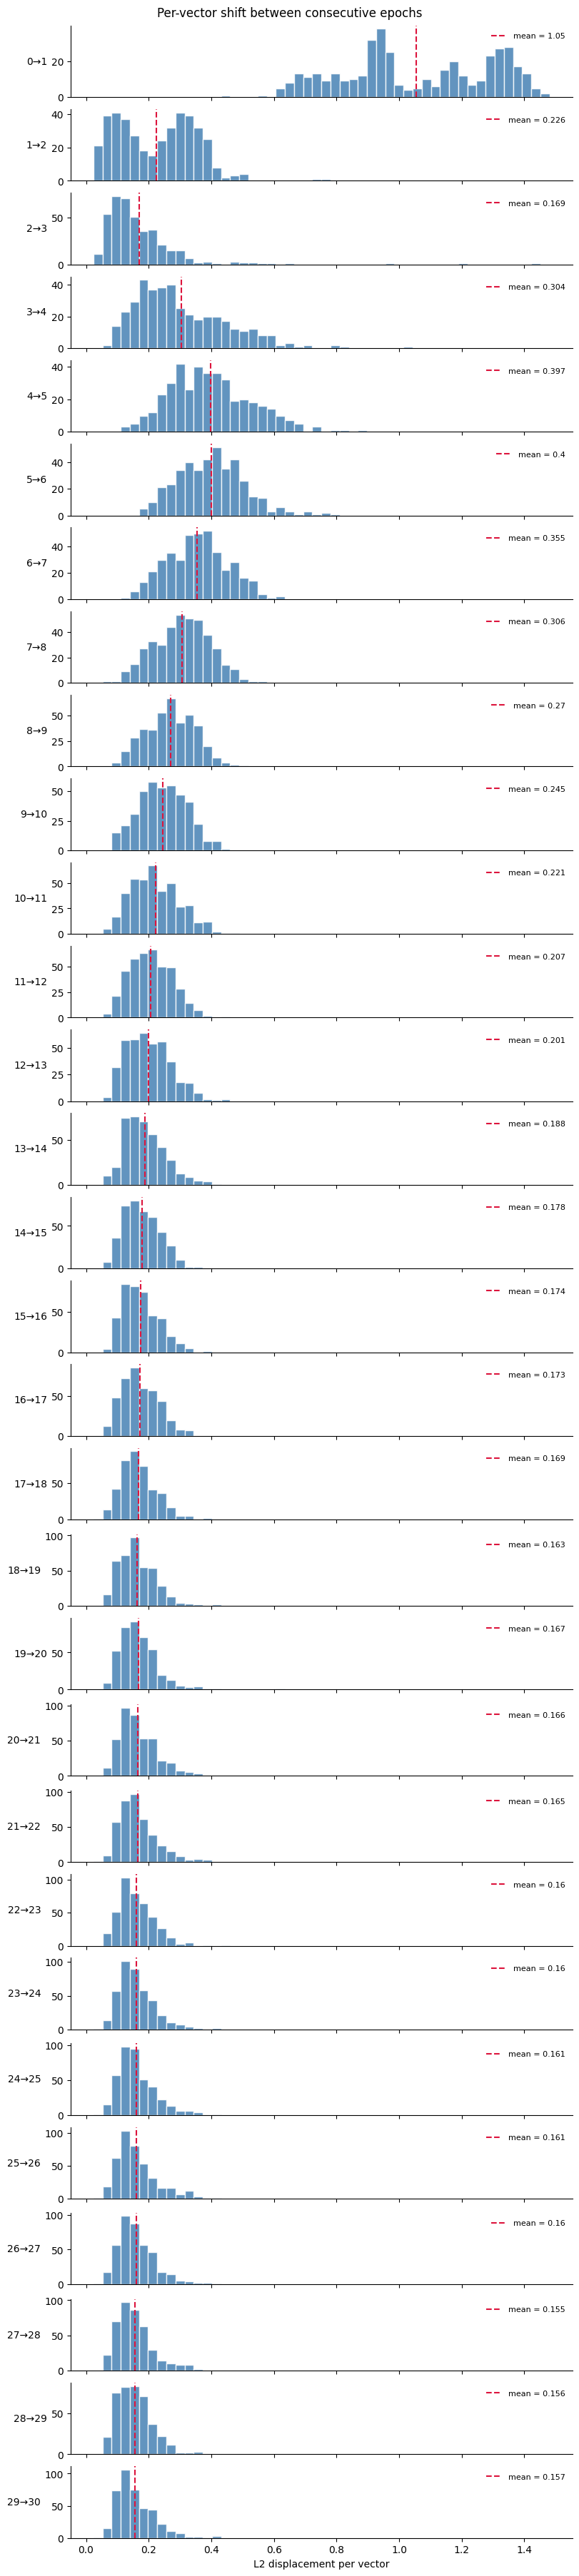

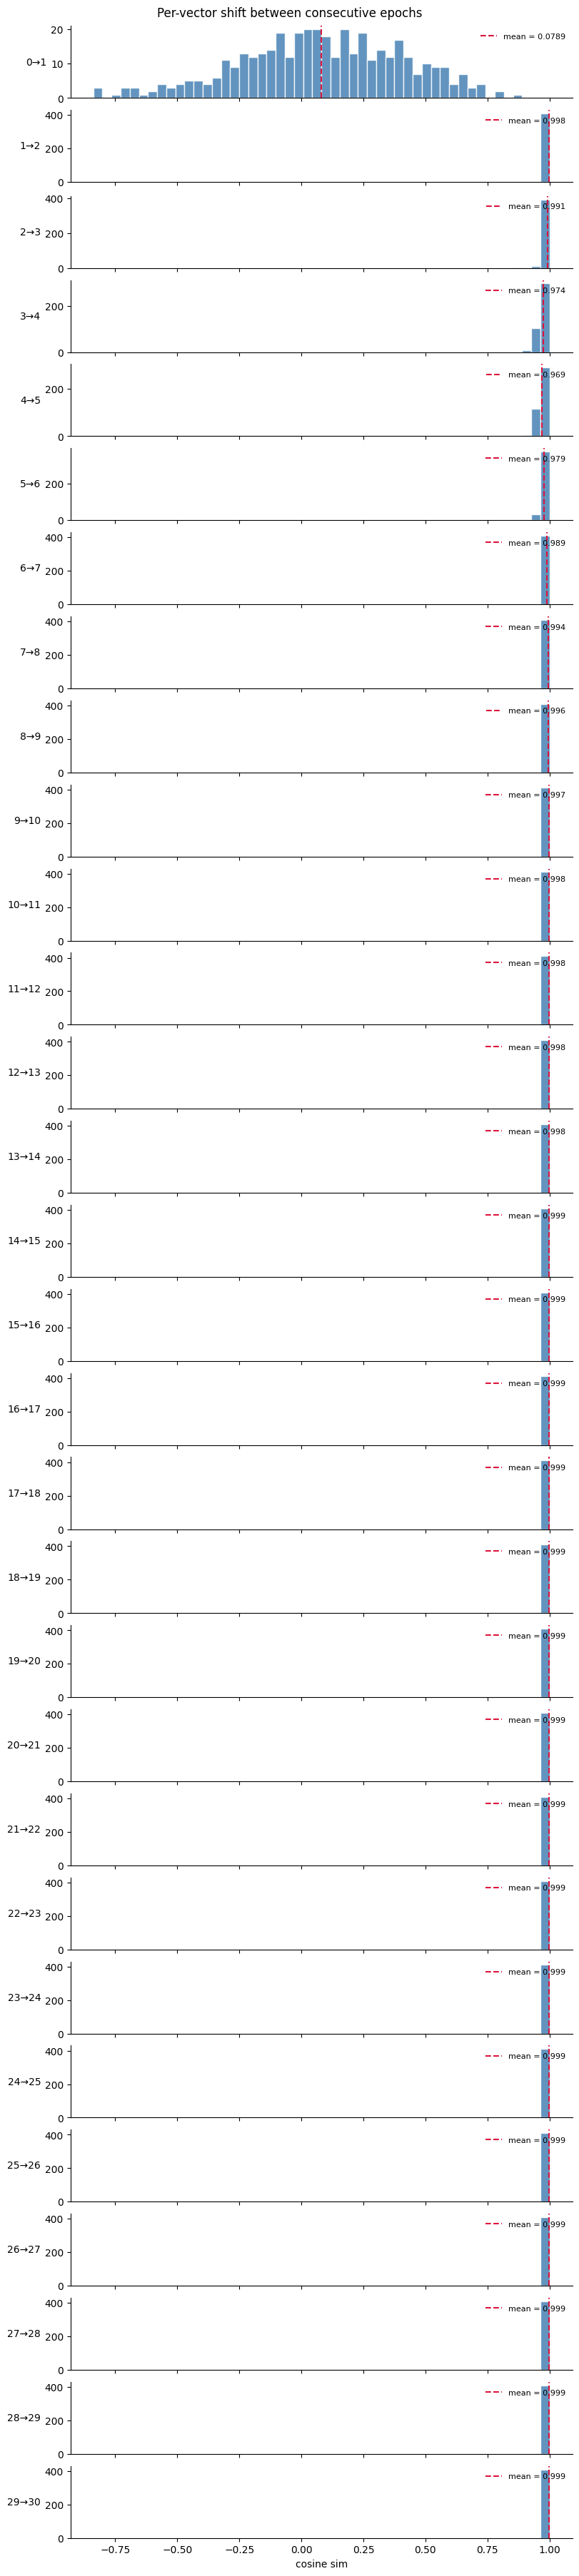

In [ ]:
plot_epoch_histograms(all_diff_eucli_SGNS, xlabel="L2 displacement per vector")
plt.show()

plot_epoch_histograms(all_diff_cos_sim_SGNS, xlabel="cosine sim")
plt.show()

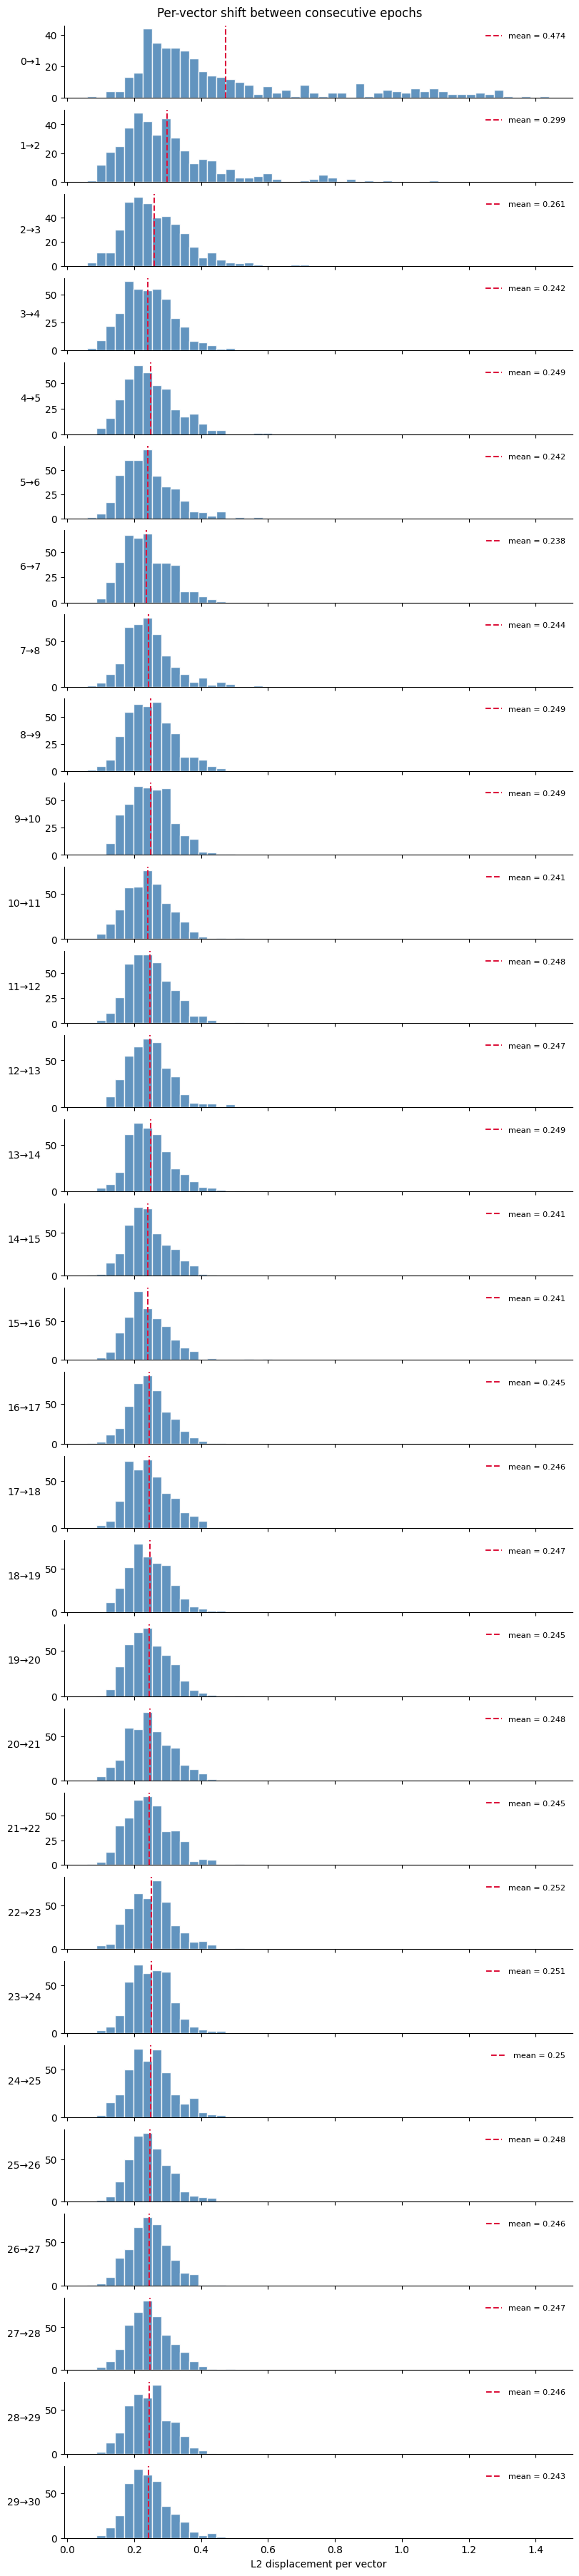

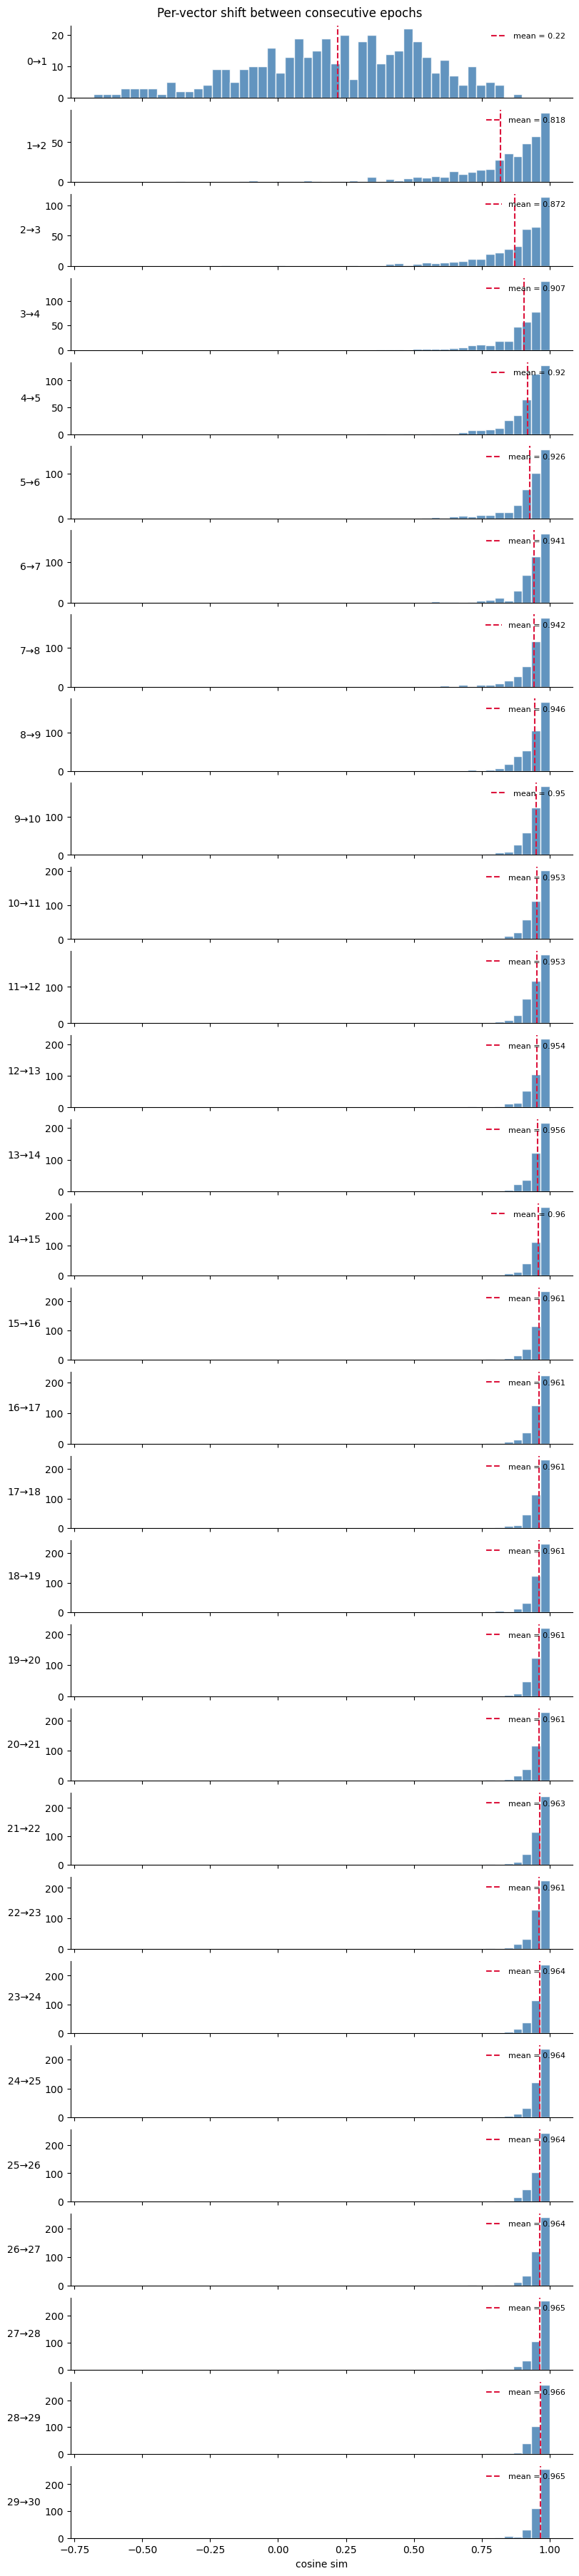

In [ ]:
plot_epoch_histograms(all_diff_eucli_ISGNS, xlabel="L2 displacement per vector")
plt.show()

plot_epoch_histograms(all_diff_cos_sim_ISGNS, xlabel="cosine sim")
plt.show()

In [ ]:
print(all_diff_eucli_SGNS[5].mean())

tensor(0.3999)


## Euclidean dist

In [ ]:
start = 10
end = len(all_diff_eucli_SGNS)

all_mean_euc = [data.mean() for data in all_diff_eucli_SGNS]

fig, axs = plt.subplots()
axs.plot(range(start, end), all_mean_euc[start : end])
fig.suptitle('SGNS - mean euclidean distance by epoch')
plt.show()

all_mean_euc_ISGNS = [data.mean() for data in all_diff_eucli_ISGNS]

fig, axs = plt.subplots()
axs.plot(range(start, end), all_mean_euc_ISGNS[start : end])
fig.suptitle('ISGNS - mean euclidean distance by epoch')
plt.show()

NameError: name 'all_diff_eucli_SGNS' is not defined

## Cosine sim

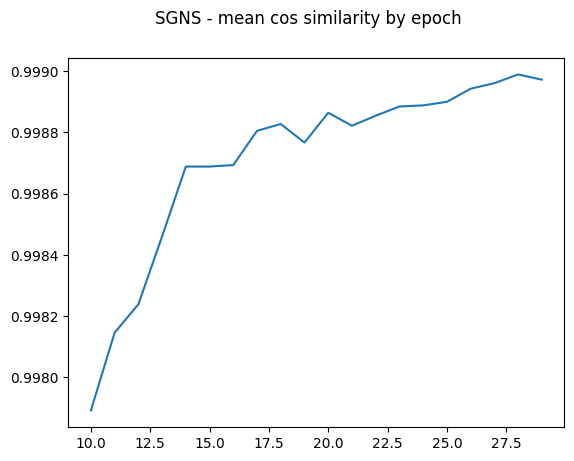

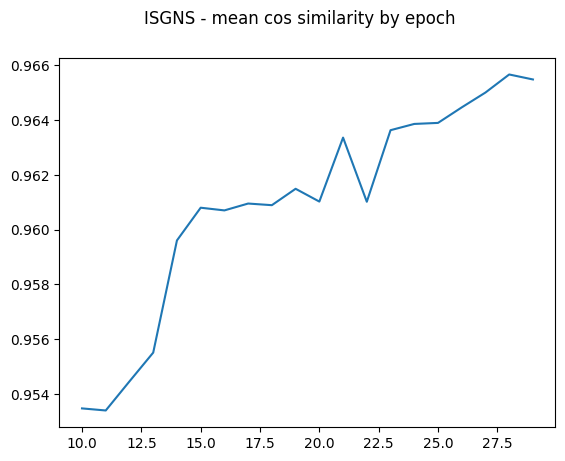

In [ ]:
start = 10
end = len(all_diff_cos_sim_SGNS)

all_mean_cos = [data.mean() for data in all_diff_cos_sim_SGNS]

fig, axs = plt.subplots()
axs.plot(range(start, end), all_mean_cos[start : end])
fig.suptitle('SGNS - mean cos similarity by epoch')
plt.show()

all_mean_cos_ISGNS = [data.mean() for data in all_diff_cos_sim_ISGNS]

fig, axs = plt.subplots()
axs.plot(range(start, end), all_mean_cos_ISGNS[start : end])
fig.suptitle('ISGNS - mean cos similarity by epoch')
plt.show()

## Line plot